--- Logistic Regression ---
Accuracy: 0.9748
Precision: 0.9502
Recall: 0.9748
              precision    recall  f1-score   support

     No Fire       0.00      0.00      0.00         8
        Fire       0.97      1.00      0.99       309

    accuracy                           0.97       317
   macro avg       0.49      0.50      0.49       317
weighted avg       0.95      0.97      0.96       317

------------------------------------------------

--- Linear Regression ---
Accuracy: 0.9748
Precision: 0.9502
Recall: 0.9748
              precision    recall  f1-score   support

     No Fire       0.00      0.00      0.00         8
        Fire       0.97      1.00      0.99       309

    accuracy                           0.97       317
   macro avg       0.49      0.50      0.49       317
weighted avg       0.95      0.97      0.96       317

------------------------------------------------

--- Random Forest ---
Accuracy: 0.9716
Precision: 0.9614
Recall: 0.9716
              precis

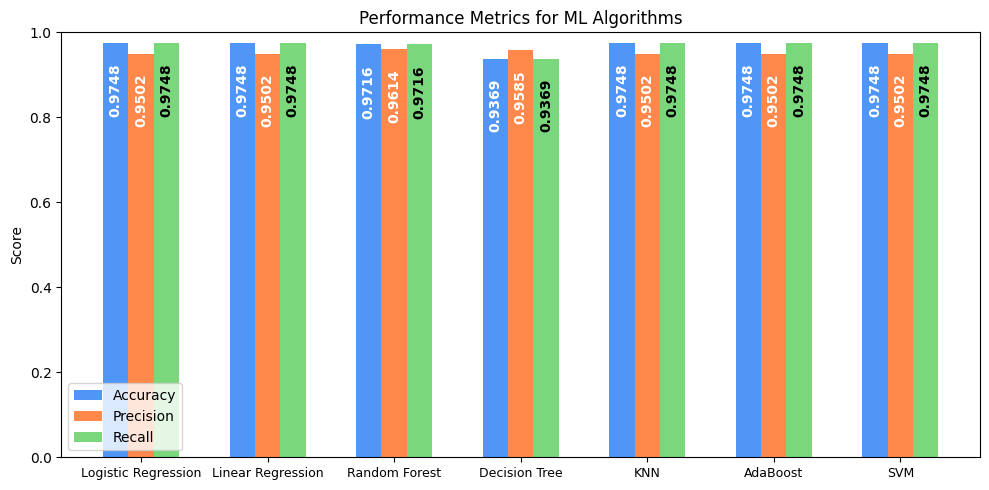

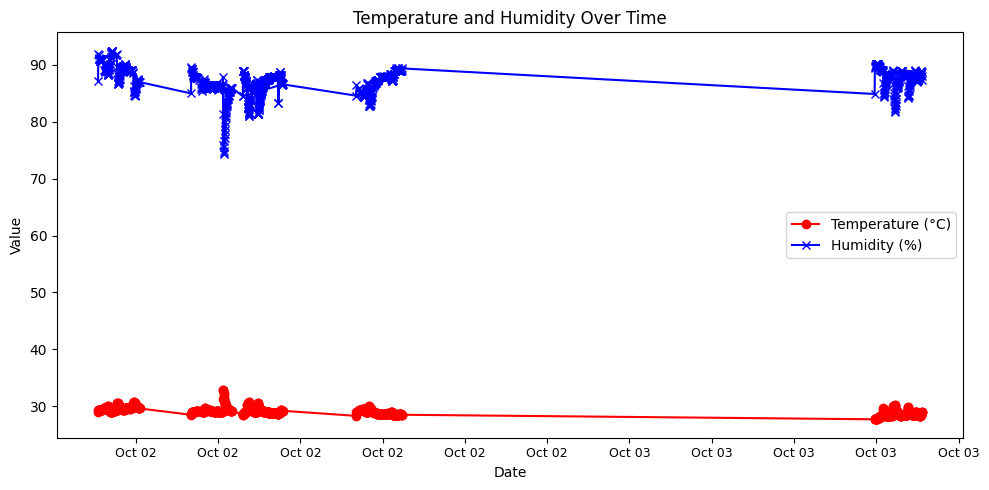

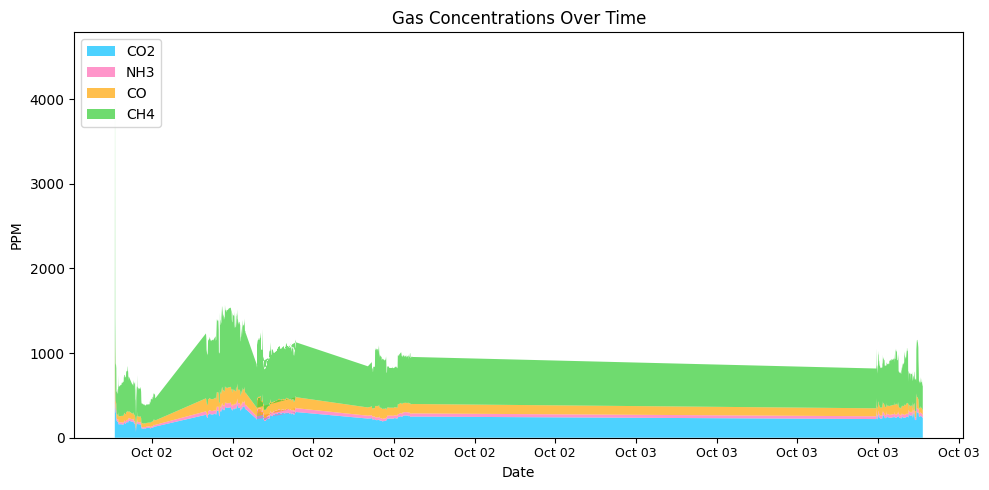

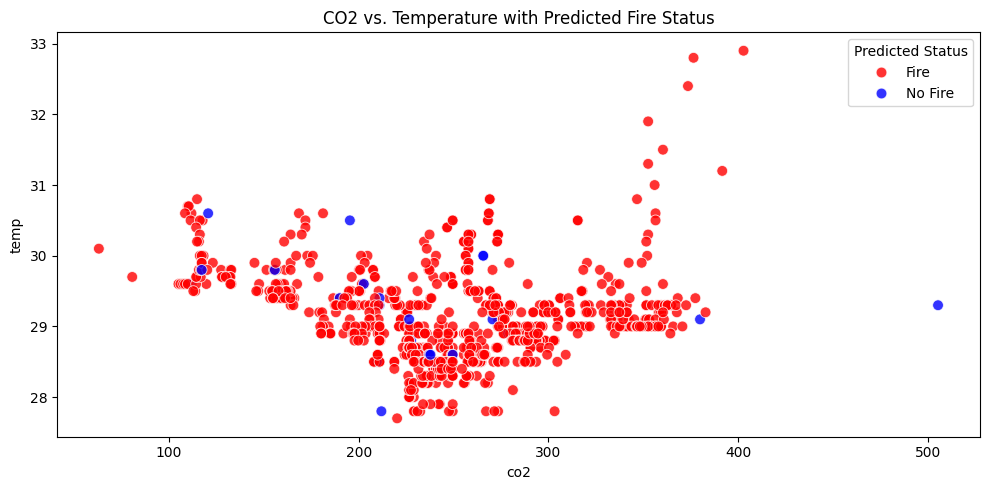

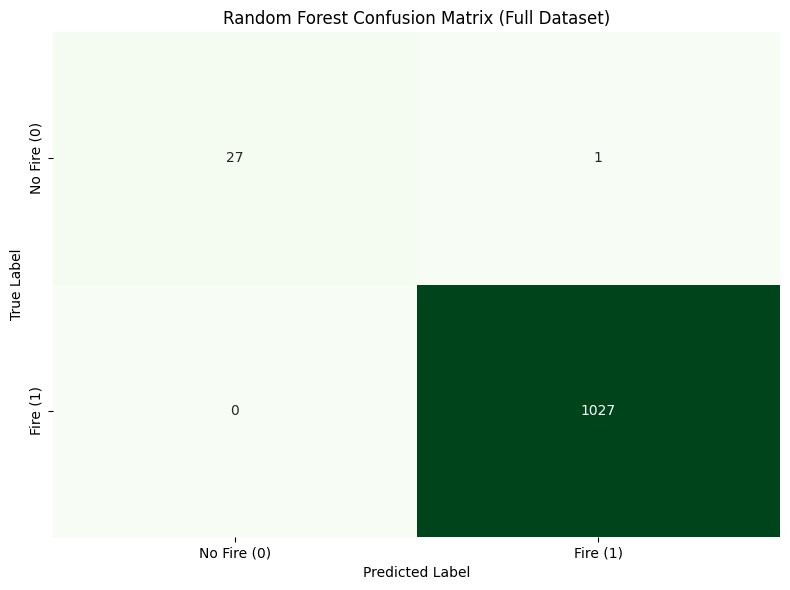

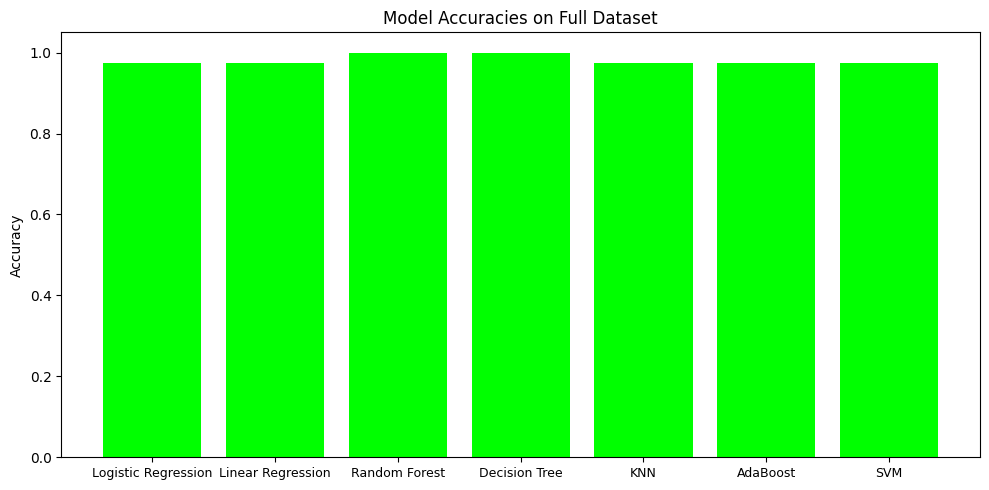

In [ ]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

# --- Step 1: Data Loading and Preprocessing ---
# Load the data and remove any rows with missing values
df = pd.read_csv('forest_fire_data.csv')
df = df.dropna()

# Clean column names by removing leading/trailing spaces
df.columns = df.columns.str.strip()

# Convert `created_at` to a proper datetime format for time-series plotting
df['created_at'] = pd.to_datetime(df['created_at'])

# Define features and the target variable
# The `flame sensor` column is the target variable (0 for no fire, 1 for fire)
# We exclude columns that are not useful for the model
exclude_cols = ['flame sensor', 'created_at', 'Entity_id', 'buzzer status']
features = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]
X = df[features].values
y = df['flame sensor'].astype(int).values # Ensure target variable is integer type

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Step 2: Define and Train Models ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=300),
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'SVM': SVC(kernel='linear', probability=True, random_state=42)
}

# The class labels are 0 and 1, so we initialize the table accordingly.
acc_table = {0: {}, 1: {}}
metrics_list = []
model_predictions = {}
model_accuracies = {}

# Train and evaluate each model
for name, model in models.items():
    if name == 'Linear Regression':
        # Linear Regression is a regression model, we handle it separately by rounding predictions
        model.fit(X_train_scaled, y_train)
        y_pred_cont = model.predict(X_test_scaled)
        y_pred = np.clip(np.round(y_pred_cont), 0, 1).astype(int)
    else:
        # All other models are classifiers
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    # Calculate and store classification metrics
    cr = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0,
        labels=[0, 1],
        target_names=['No Fire', 'Fire']
    )

    # Corrected section: Safely access classification report keys
    if '0' in cr:
        acc_table[0][name] = cr['0']['recall']
    else:
        acc_table[0][name] = 0

    if '1' in cr:
        acc_table[1][name] = cr['1']['recall']
    else:
        acc_table[1][name] = 0

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    metrics_list.append({'Model': name, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall})

    # Print a summary of the evaluation for each model
    print(f'--- {name} ---')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(classification_report(y_test, y_pred, labels=[0, 1], target_names=['No Fire', 'Fire'], zero_division=0))
    print('------------------------------------------------\n')

# --- Step 3: Performance Visualization ---
acc_df = pd.DataFrame(acc_table).T
acc_df.index.name = 'Fire Status'

print("Per-class Accuracy (Recall) Table:")
print(acc_df.round(4))

metrics_df = pd.DataFrame(metrics_list)

# Bar chart for overall model performance
plt.figure(figsize=(10, 5))
bar_width = 0.2
x = np.arange(len(metrics_df))
bars1 = plt.bar(x - bar_width, metrics_df['Accuracy'], width=bar_width, color='#5096f7', label='Accuracy')
bars2 = plt.bar(x, metrics_df['Precision'], width=bar_width, color='#ff884a', label='Precision')
bars3 = plt.bar(x + bar_width, metrics_df['Recall'], width=bar_width, color='#7bd77c', label='Recall')

# Add text labels on the bars
for bars, color in zip([bars1, bars2, bars3], ['#5096f7', '#ff884a', '#7bd77c']):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height - (height * 0.05),
            f"{height:.4f}",
            ha='center',
            va='top',
            color='white' if color != '#7bd77c' else 'black',
            fontsize=10,
            fontweight='bold',
            rotation='vertical'
        )

plt.xticks(x, metrics_df['Model'], ha='center', fontsize=9)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Performance Metrics for ML Algorithms')
plt.legend()
plt.tight_layout()
plt.show()

# --- Step 4: Time-Series Data Visualization ---
# Predict on the full dataset for visualization purposes
for name, model in models.items():
    if name == 'Linear Regression':
        model.fit(scaler.transform(X), y)
        predictions = np.clip(np.round(model.predict(scaler.transform(X))), 0, 1).astype(int)
    else:
        model.fit(scaler.transform(X), y)
        predictions = model.predict(scaler.transform(X))
    model_predictions[name] = predictions
    model_accuracies[name] = accuracy_score(y, predictions)

# Using Random Forest predictions for the visualizations
df['Predicted Status'] = np.where(model_predictions["Random Forest"] == 1, 'Fire', 'No Fire')
color_dict = {'Fire': 'red', 'No Fire': 'blue'}

# Plot Temperature and Humidity over time
plt.figure(figsize=(10, 5))
plt.plot(df['created_at'], df['temp'], label='Temperature (°C)', color='red', marker='o')
plt.plot(df['created_at'], df['humd'], label='Humidity (%)', color='blue', marker='x')
plt.title('Temperature and Humidity Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.gca().xaxis.set_major_formatter(DateFormatter('%b %d'))
plt.xticks(ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Plot Gas concentrations as a stacked area chart
plt.figure(figsize=(10, 5))
plt.stackplot(df['created_at'], df['co2'], df['nh3'], df['co'], df['ch4'],
              labels=['CO2', 'NH3', 'CO', 'CH4'], colors=['#00bfff', '#ff69b4', '#ffa500', '#32cd32'], alpha=0.7)
plt.legend(loc='upper left')
plt.title('Gas Concentrations Over Time')
plt.xlabel('Date')
plt.ylabel('PPM')
plt.gca().xaxis.set_major_formatter(DateFormatter('%b %d'))
plt.xticks(ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Plot Gas correlation with fire status using a scatter plot
plt.figure(figsize=(10, 5))
sns.scatterplot(x='co2', y='temp', hue='Predicted Status', data=df,
                palette=color_dict, s=60, alpha=0.8)
plt.title('CO2 vs. Temperature with Predicted Fire Status')
plt.tight_layout()
plt.show()

# Plot a Confusion Matrix for the Random Forest model on the full dataset
conf_matrix = confusion_matrix(y, model_predictions["Random Forest"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No Fire (0)', 'Fire (1)'],
            yticklabels=['No Fire (0)', 'Fire (1)'])
plt.title('Random Forest Confusion Matrix (Full Dataset)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Plot a bar chart showing the overall accuracies of all models
plt.figure(figsize=(10, 5))
plt.bar(list(model_accuracies.keys()), list(model_accuracies.values()), color='lime')
plt.title('Model Accuracies on Full Dataset')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.xticks(ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
|